<a href="https://colab.research.google.com/github/NinaNikolova/data_mining_project/blob/main/python_games15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clustering

In [1]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()

Mounted at /content/drive


Saving video_game_reviews.csv to video_game_reviews.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR, OneClassSVM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.svm import LinearSVC,  LinearSVR, SVC
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import joblib
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/video_game_reviews.csv')
df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [4]:
numeric_df = df.select_dtypes(include=['number'])  # само числовите колони
attributes = numeric_df.values  # сега вече е подходящо за KMeans

In [5]:
k_means = KMeans(n_clusters=3, random_state=42)


In [6]:
df['cluster'] = k_means.fit_predict(attributes)

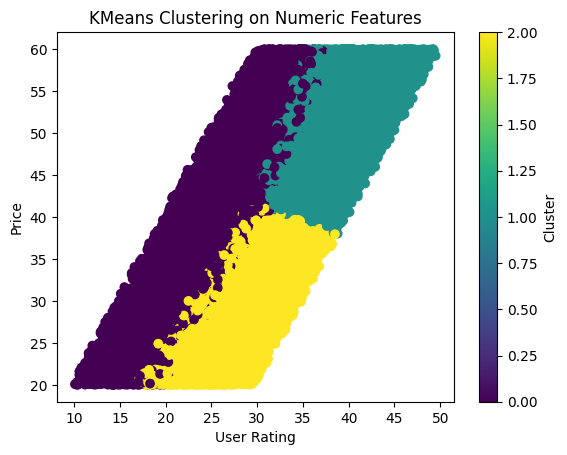

In [7]:
plt.scatter(attributes[:, 0], attributes[:, 1], c=df['cluster'], cmap='viridis')
plt.xlabel(numeric_df.columns[0])
plt.ylabel(numeric_df.columns[1])
plt.title('KMeans Clustering on Numeric Features')
plt.colorbar(label='Cluster')
plt.show()

In [8]:
score = silhouette_score(attributes, k_means.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.3481663166031628


Silhouette Score измерва колко добре са оформени клъстерите.

Стойността му е между -1 и 1.

Близо до 1 — точките са добре групирани в собствените си клъстери и ясно отделени от другите.

Близо до 0 — точките са на границата между клъстери (слабо разграничение).

Отрицателна стойност — точките може да са поставени в грешен клъстер.
-Това означава средно слабо до умерено добро разделяне на клъстерите.

- Клъстерите не са много ясни, но има някаква структура.



In [9]:
k_means2 = KMeans(init='random')
k_means2.fit(attributes)

KMeans(init='random')

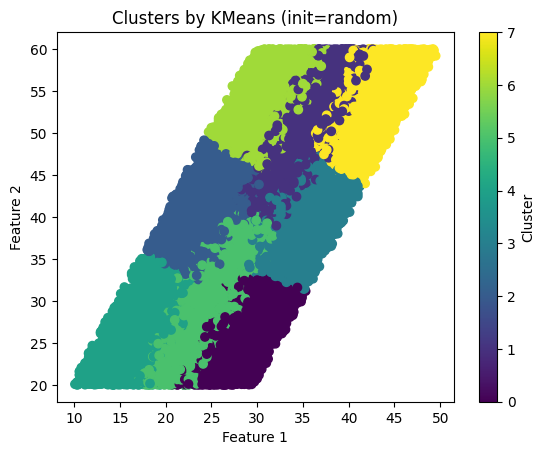

In [10]:
plt.scatter(attributes[:, 0], attributes[:, 1], c=k_means2.labels_, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clusters by KMeans (init=random)')
plt.colorbar(label='Cluster')
plt.show()

In [11]:
# Inertia: sum of squared distances of samples to their closest cluster center
print("Inertia:", k_means2.inertia_)

# Silhouette Score: how well-separated clusters are
score = silhouette_score(attributes, k_means2.labels_)
print("Silhouette Score:", score)


Inertia: 3833435.1514969044
Silhouette Score: 0.27576385430292033


In [12]:
# Split data (e.g. 80% train, 20% test)
X_train, X_test = train_test_split(attributes, test_size=0.2, random_state=42)

# Train KMeans on training data
k_means3 = KMeans(n_clusters=3, random_state=42)
k_means3.fit(X_train)

KMeans(n_clusters=3, random_state=42)

In [13]:
# Predict clusters on test data
test_labels = k_means3.predict(X_test)

In [14]:
# Evaluate clustering quality on test data
score = silhouette_score(X_test, test_labels)
print("Silhouette Score on test set:", score)

Silhouette Score on test set: 0.3551802590871481


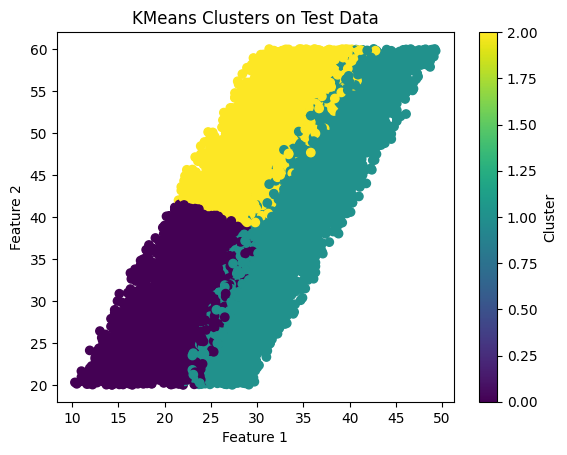

In [15]:
# Plot scatter for test data (using first two numeric features)
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clusters on Test Data')
plt.colorbar(label='Cluster')
plt.show()


In [16]:
# Silhouette score for test data
score = silhouette_score(X_test, test_labels)
print("Silhouette Score on test set:", score)

Silhouette Score on test set: 0.3551802590871481


In [17]:
k_means3.cluster_centers_

array([[  21.14215446,   29.61940328, 2016.51983226,   21.2337061 ,
           5.12773021],
       [  34.7240694 ,   40.54624192, 2016.48181874,   48.12169446,
           5.11081031],
       [  31.39826996,   50.37403042, 2016.50209125,   20.63937262,
           5.11986692]])

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

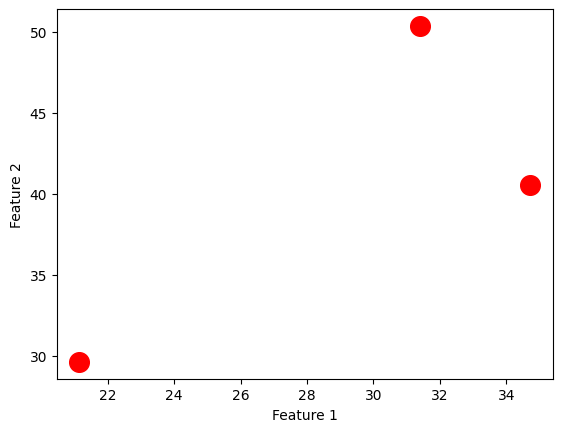

In [18]:
plt.scatter(k_means3.cluster_centers_[:, 0], k_means3.cluster_centers_[:, 1], s=200, c='red', label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt